# Example Plots and Processing of Pipeline Analysis

In [2]:
# Import functions from the pipeline_fxn_lib.py script
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import Rectangle
import xarray as xr
import yaml

In [3]:
# Define a consistent color scheme for GRUAN and ERA5 data
color_gruan = 'tab:green'
color_era5 = 'tab:blue'
color_gaussian = 'blue'  # For initial condition Gaussian, if needed

# Example usage:
# plt.plot(x_gruan, y_gruan, color=color_gruan, label='GRUAN')
# plt.plot(x_era5, y_era5, color=color_era5, label='ERA5')

## Downloaded and Processed ERA5 and GRUAN Data

## Process and Plot RHi Data

### Plot RHi Histogram

In [4]:
mean, std_dev, filtered_gruan_rhi, filtered_era5_rhi = lib.post_process_met_data()

Output file already exists. Skipping combination.


In [5]:
counts, xedges, yedges = np.histogram2d(filtered_gruan_rhi, filtered_era5_rhi, bins=50)

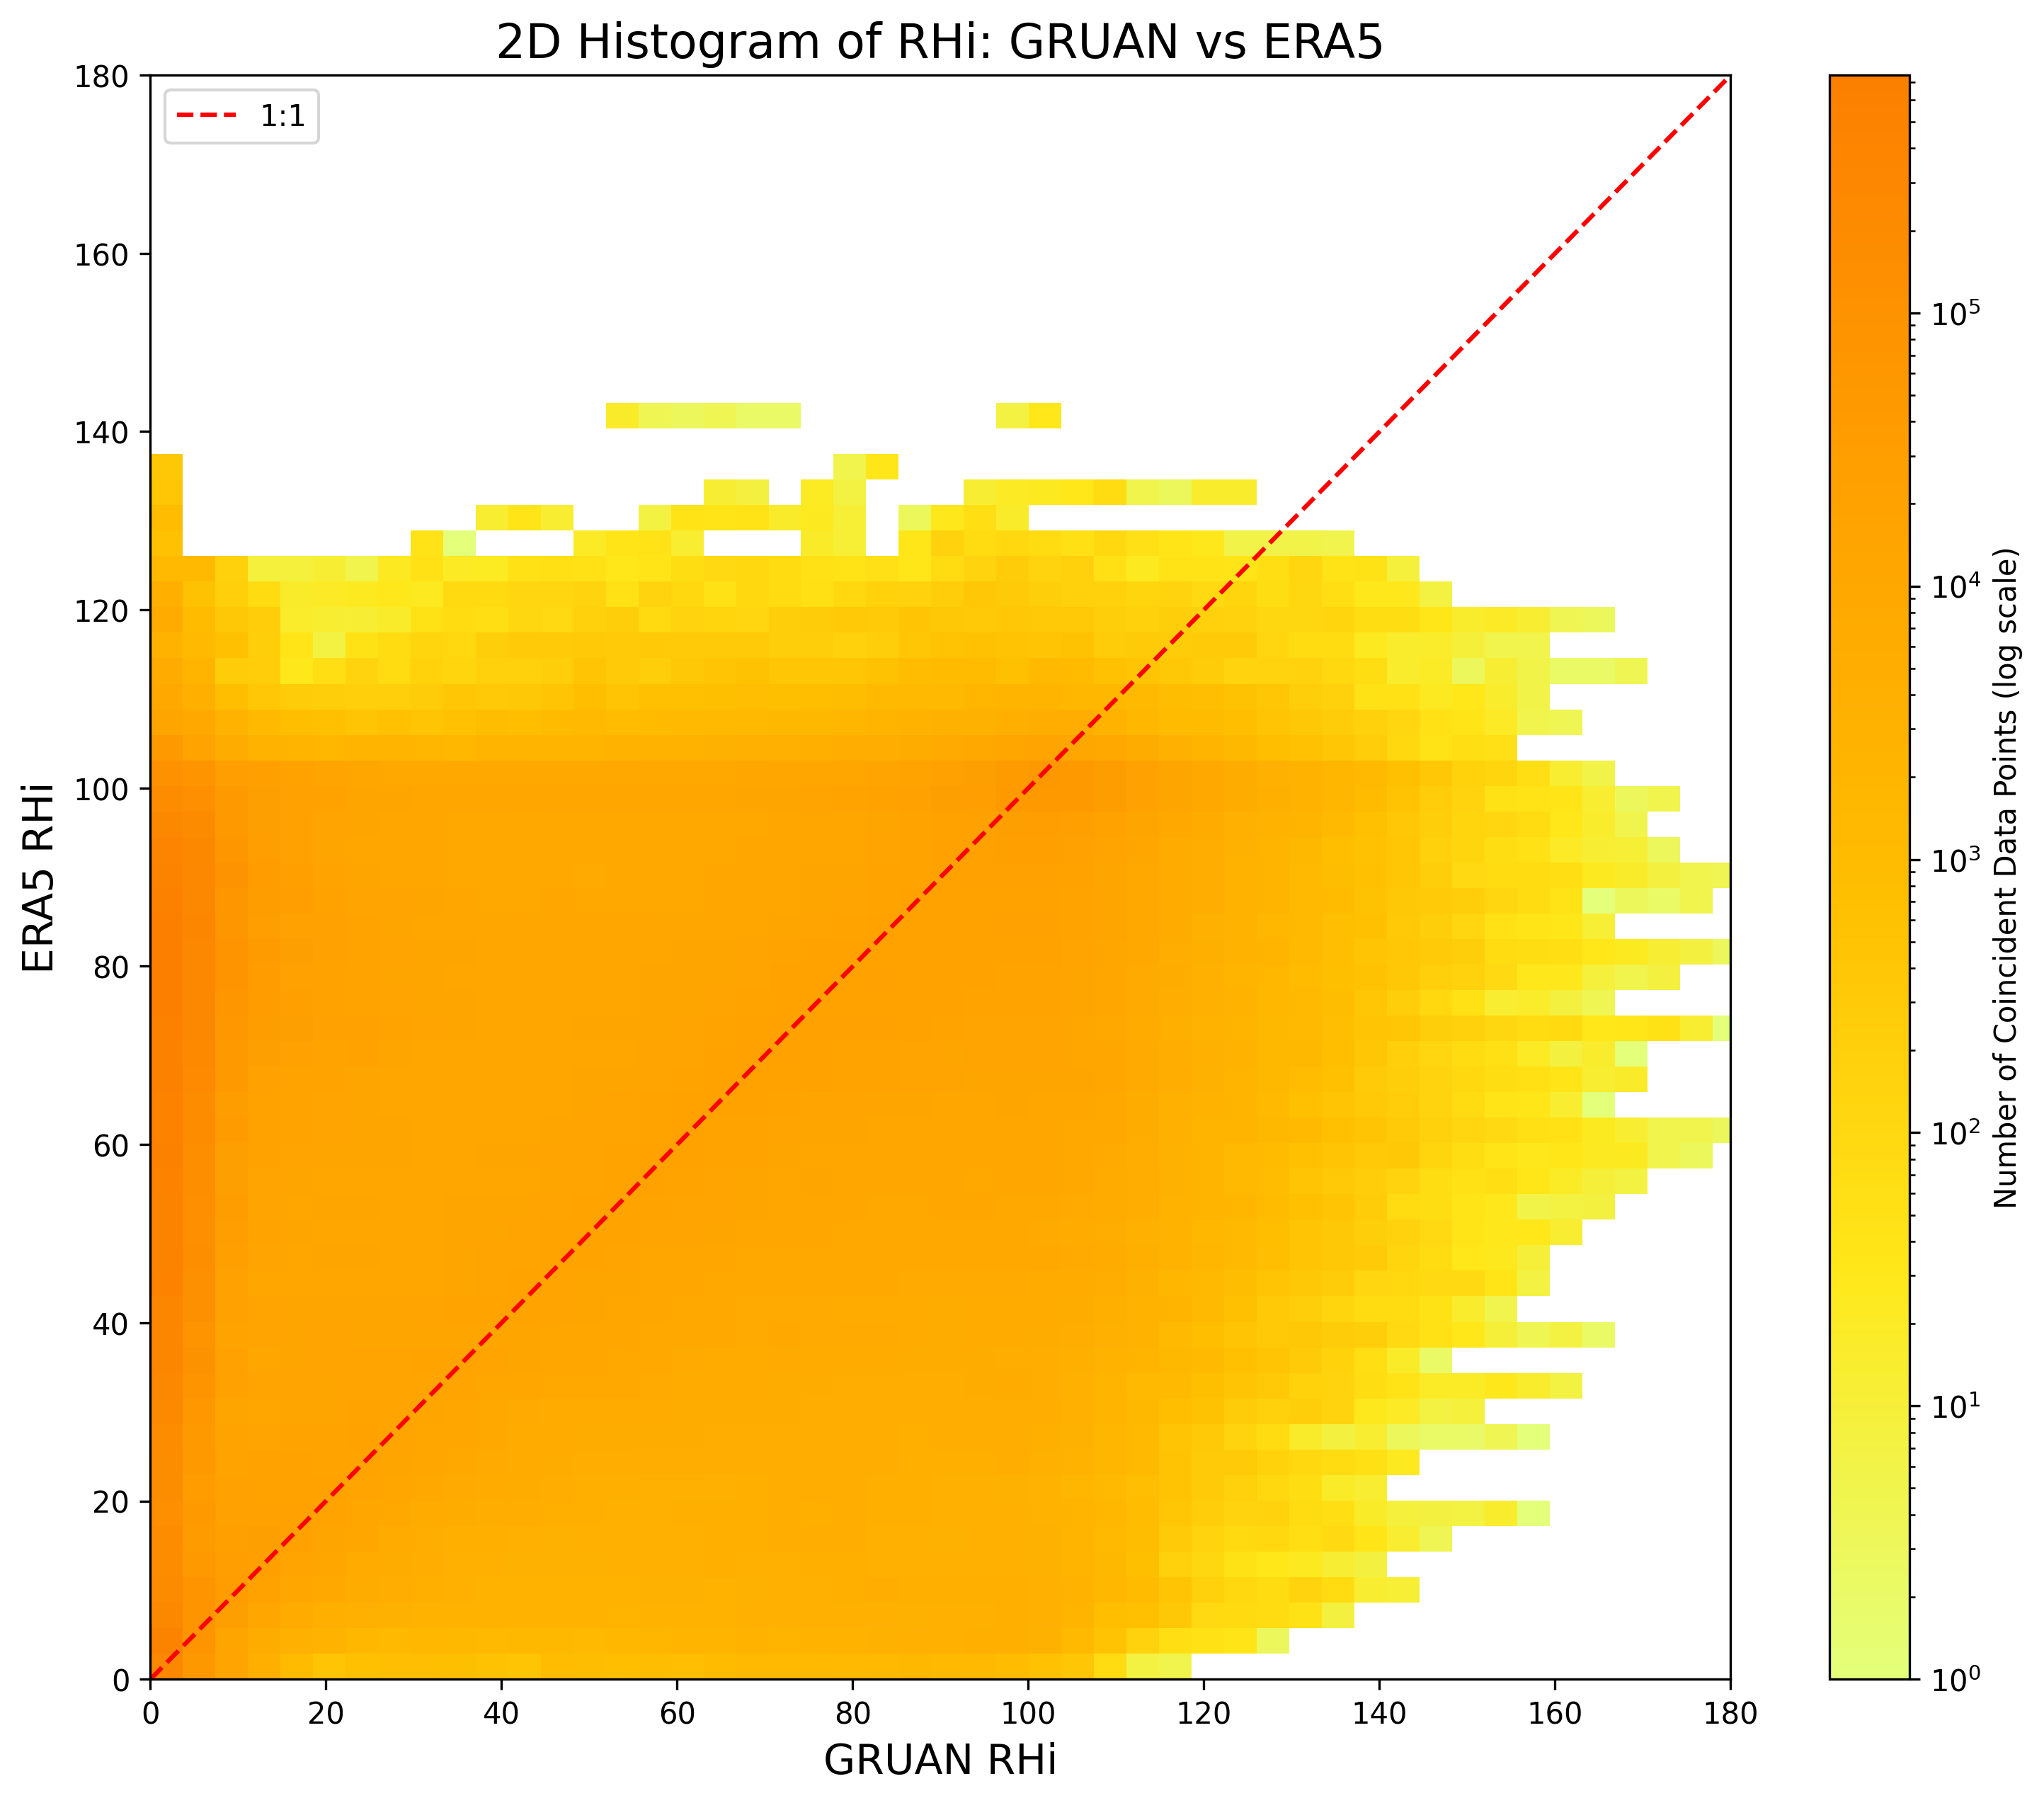

In [5]:
plt.figure(figsize=(12,10), dpi=300)

# Mask zero values in counts to avoid log(0)
# masked_counts = np.ma.masked_where(counts == 0, counts)
masked_counts = np.ma.masked_array(counts, mask=(counts == 0))

# Set up LogNorm with safe min/max (log can't handle 0)
norm = LogNorm(vmin=masked_counts.min(), vmax=masked_counts.max())

# Display using imshow with LogNorm
im = plt.imshow(
    masked_counts.T,
    origin='lower',
    aspect='auto',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='Wistia',
    norm=norm
)

plt.xlabel('GRUAN RHi', fontsize=14)
plt.ylabel('ERA5 RHi', fontsize=14)
plt.ylim(bottom=0, top=180)
plt.xlim(left=0, right=180)
plt.title('2D Histogram of RHi: GRUAN vs ERA5', fontsize=16)
plt.plot([0,max(filtered_gruan_rhi)],[0,max(filtered_gruan_rhi)], 'r--', label='1:1')
plt.legend()

# Add colorbar with correct scaling
cbar = plt.colorbar(im, label='Number of Coincident Data Points (log scale)')


In [8]:
df_combined = pd.read_parquet('/home/chinahg/GCresearch/contrailuncertainty/start_here/generated_files/combined_data.parquet')

In [10]:
# Fit the ERA5 data to a Gaussian distribution, but only for RHi values between 90 and 140
era5_rhi_input = filtered_era5_rhi[(filtered_era5_rhi >= 110) & (filtered_era5_rhi <= 140)]
mirror_data = 2*3 - era5_rhi_input + 214
# Combine the original and mirrored data
combined_data = np.concatenate((era5_rhi_input, mirror_data))
# Fit a Gaussian distribution to the combined data
mean = np.mean(combined_data)
std_dev = np.std(combined_data)
print(f"Mean: {mean}, Standard Deviation: {std_dev}")

gaussian_samples = np.random.normal(mean, std_dev, 10000) # This is how we will sample the initial conditions

Mean: 110.0, Standard Deviation: 7.790676323911221


## Plot GRUAN vs ERA 5 histogram

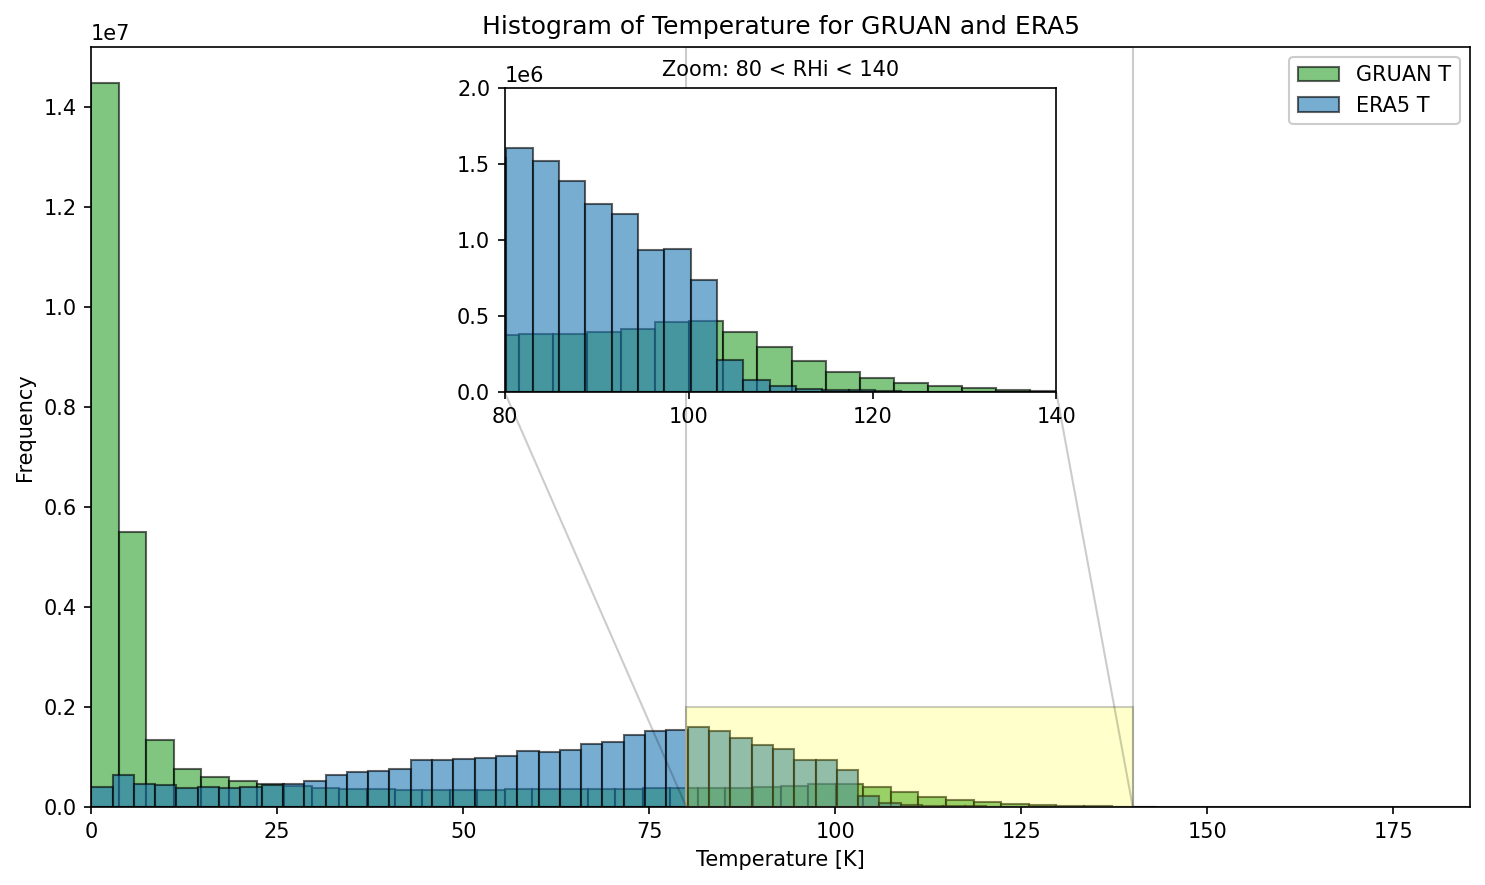

In [ ]:
gruan_max = max(filtered_gruan_rhi)

plt.figure(figsize=(10,6), dpi=150)
plt.hist(filtered_gruan_rhi, bins=50, alpha=0.6, label='GRUAN RHi', color=color_gruan, edgecolor='black')
plt.hist(filtered_era5_rhi, bins=50, alpha=0.6, label='ERA5 RHi', color=color_era5, edgecolor='black')
plt.xlabel('RHi [%]')
plt.ylabel('Frequency')
plt.title('Histogram of RHi for GRUAN and ERA5')
plt.legend(loc='upper right', framealpha=1)
plt.xlim(0, gruan_max)
plt.tight_layout()

# Add magnified inset for 80 < RHi < gruan_max
ax = plt.gca()
axins = inset_axes(ax, width="40%", height="40%", loc='upper center', borderpad=2)
axins.hist(filtered_gruan_rhi, bins=50, alpha=0.6, color=color_gruan, edgecolor='black')
axins.hist(filtered_era5_rhi, bins=50, alpha=0.6, color=color_era5, edgecolor='black')
axins.set_xlim(80, 140)
axins.set_ylim(0,2000000)
axins.set_xticks(np.linspace(80, 140, 4, dtype = int))
axins.set_yticks(np.linspace(0, 2000000, 5, dtype = int))
axins.set_title('Zoom: 80 < RHi < 140', fontsize=10)

# Draw a box on the main plot to show the zoomed region
rect = Rectangle((80, 0), 140-80, ax.get_ylim()[1], linewidth=1, edgecolor='0.8', facecolor='none')
ax.add_patch(rect)
mark_inset(ax, axins, loc1=3, loc2=4, fc="yellow", ec="0", alpha = 0.2)

plt.show()

### Plot the absolute percent difference between ERA5 and GRUAN co-located RHi values

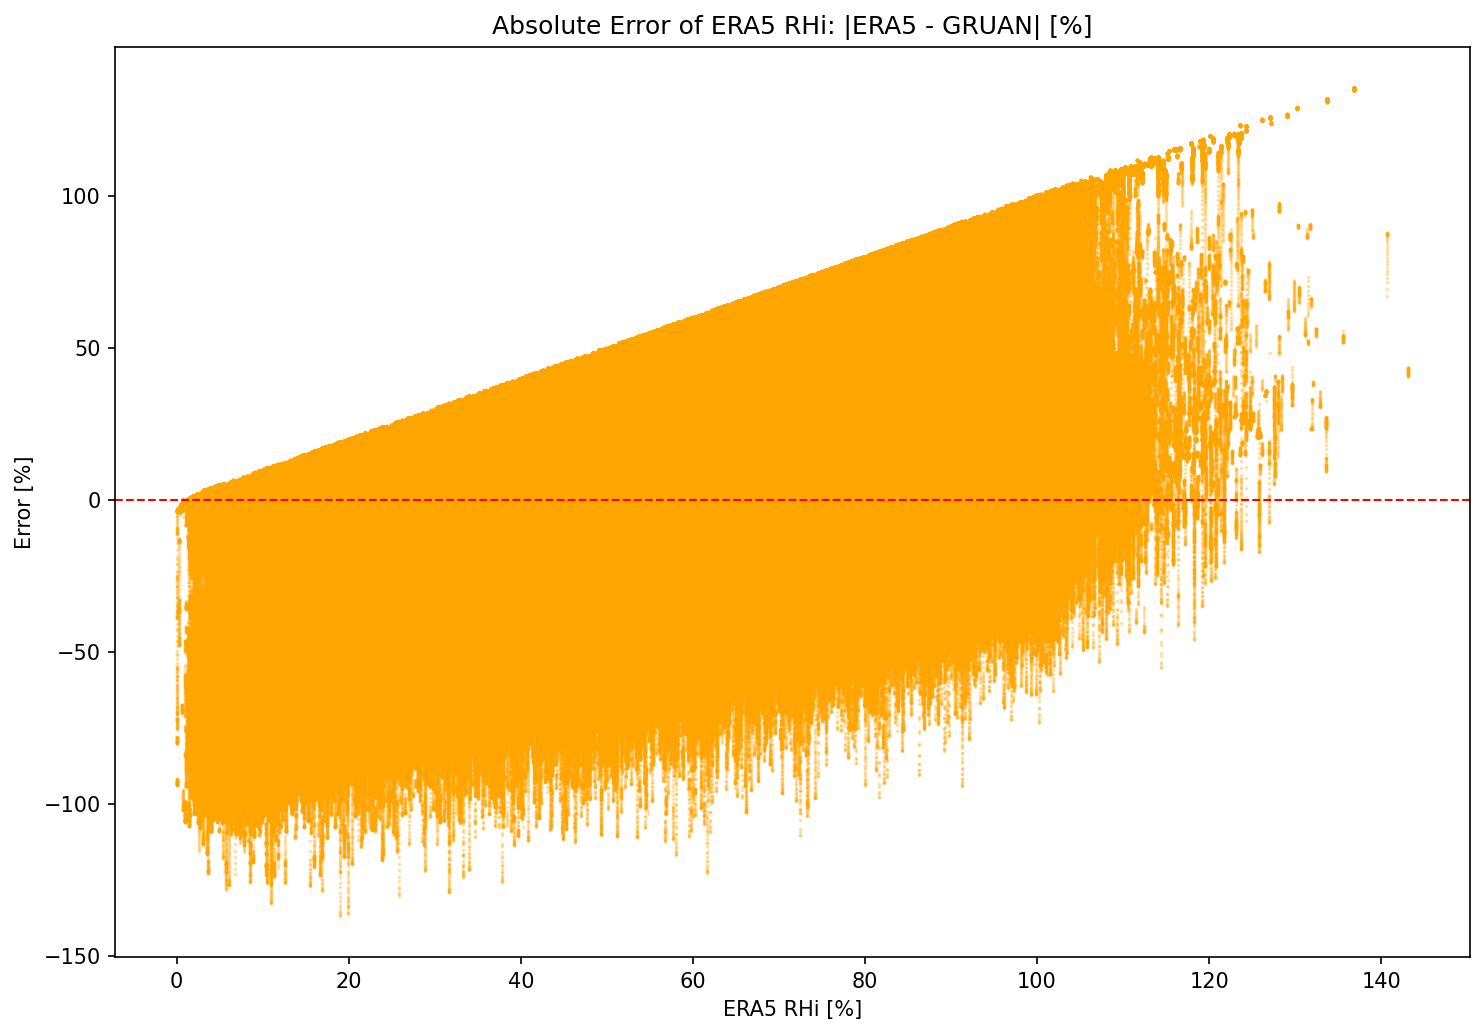

In [11]:
# Compute the difference between ERA5 and GRUAN RHi values
rhi_diff = np.array(filtered_era5_rhi) - np.array(filtered_gruan_rhi)

plt.figure(figsize=(10, 7), dpi=150)
plt.scatter(filtered_era5_rhi, rhi_diff, alpha=0.3, s=0.5, color='orange')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('ERA5 RHi [%]')
plt.ylabel('Error [%]')
plt.title('Absolute Error of ERA5 RHi: |ERA5 - GRUAN| [%]')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Absolute Difference between ERA5 and GRUAN RHi vs ERA5 RHi Samples')

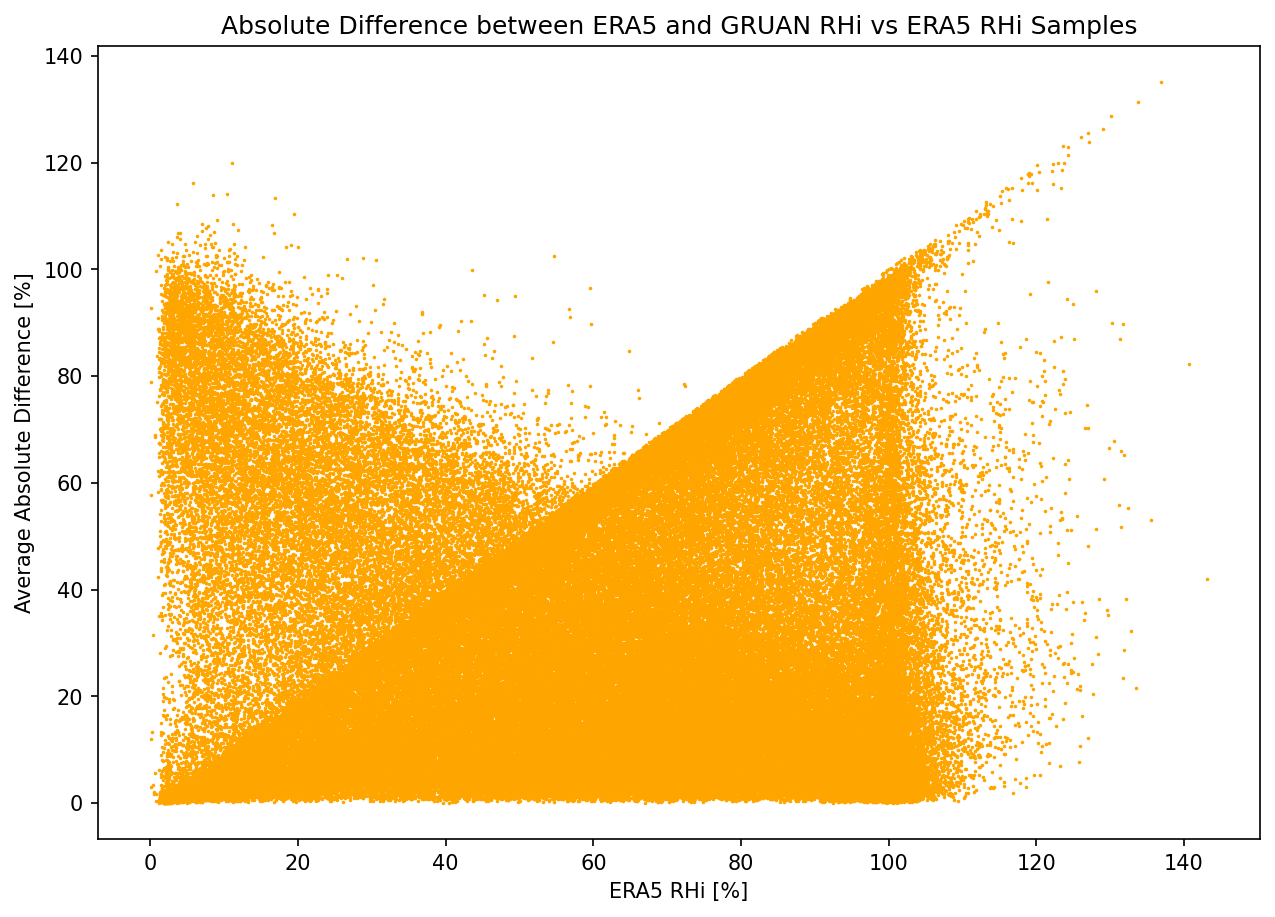

In [12]:
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# Compute the difference between ERA5 and GRUAN RHi values
rhi_diff = abs(np.array(filtered_era5_rhi) - np.array(filtered_gruan_rhi))

# Group by unique RHi values and compute the average rhi_diff for each unique value

# Convert to pandas Series for grouping
era5_rhi_series = pd.Series(filtered_era5_rhi)
rhi_diff_series = pd.Series(rhi_diff)

# Group by unique ERA5 RHi values and compute the mean of rhi_diff for each
avg_diff_by_rhi = rhi_diff_series.groupby(era5_rhi_series).mean()

# Prepare x and y data from the avg_diff_by_rhi Series
x = avg_diff_by_rhi.index.values
y = avg_diff_by_rhi.values

# Plot the LOWESS smoothed curve
plt.figure(figsize=(10, 7), dpi=150)
plt.scatter(x, y, alpha=1, s=0.5, color='orange')
plt.xlabel('ERA5 RHi [%]')
plt.ylabel('Average Absolute Difference [%]')
plt.title('Absolute Difference between ERA5 and GRUAN RHi vs ERA5 RHi Samples')

/tmp/ipykernel_2060817/108408492.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_means = pd.Series(y).groupby(binned).mean()


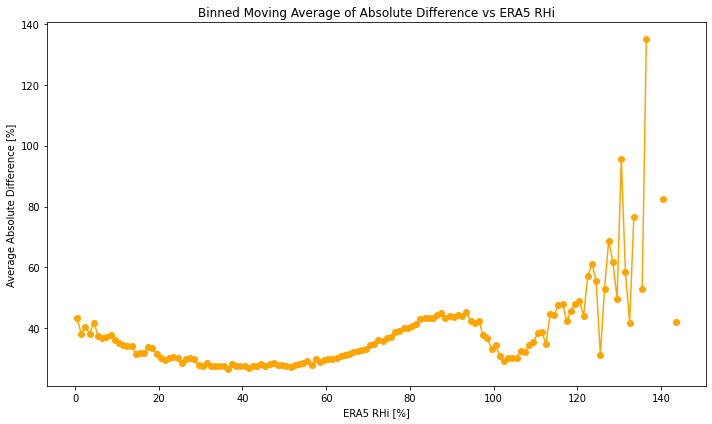

In [15]:
bin_width = 1
bins = np.arange(x.min(), x.max() + bin_width, bin_width)
bin_labels = (bins[:-1] + bins[1:]) / 2

# Bin the x values
binned = pd.cut(x, bins, labels=bin_labels, include_lowest=True)
binned_means = pd.Series(y).groupby(binned).mean()

plt.figure(figsize=(10, 6))
plt.plot(bin_labels, binned_means, marker='o', linestyle='-', color='orange')
plt.xlabel('ERA5 RHi [%]')
plt.ylabel('Average Absolute Difference [%]')
plt.title('Binned Moving Average of Absolute Difference vs ERA5 RHi')
plt.tight_layout()
plt.show()


### Create Gaussians based on initial conditions

In [ ]:
input_rhi_matrix = 

In [13]:
std = np.std(input_rhi_matrix[1,:])
mean = np.mean(input_rhi_matrix[1,0])
initial_condition_RHi = input_rhi_matrix[1,0]

x_gaussian = np.linspace(mean - 3*std, mean + 3*std, 1000)
y_gaussian = np.exp(-((x_gaussian-mean)/std)**2 / 2) / np.sqrt(2 * np.pi)

NameError: name 'input_rhi_matrix' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
plt.plot(x_gaussian, y_gaussian, color='orange', linewidth=2)
plt.axvline(initial_condition_RHi, color='0.5', linestyle='--', linewidth=1)

# Add ±1, ±2, ±3 std markers and shaded regions
for n, color, alpha in zip([1, 2, 3], ['#a6cee3', '#1f78b4', '#b2df8a'], [0.25, 0.15, 0.08]):
    left = initial_condition_RHi - n*std
    right = initial_condition_RHi + n*std
    plt.axvline(left, color=color, linestyle=':', linewidth=1)
    plt.axvline(right, color=color, linestyle=':', linewidth=1)
    plt.fill_between(x_gaussian, 0, y_gaussian, where=(x_gaussian >= left) & (x_gaussian <= right), color=color, alpha=alpha, label=f'±{n}σ')

# Add text annotation for standard error and standard deviation
# plt.text(
#     0.98, 0.95,
#     f'Reported Error = $\pm${IC_error:.2f}%\nStandard Deviation, σ = {std:.2f}%',
#     transform=ax.transAxes,
#     fontsize=12,
#     ha='right',
#     va='top',
#     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
# )

# plt.ylim(0, 0.04)
plt.legend(loc='upper left')
plt.xlabel('RHi')
plt.ylabel('Probability Density')
plt.title('Initial Condition Error Informed Uncertainty')

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Sample initial conditions
initial_conditions = np.linspace(20, 150, 3000)

# For each initial condition, compute the corresponding error and Gaussian
rhi_grid = []
pdf_grid = []

for ic in initial_conditions:
    idx = (np.abs(x - ic)).argmin()
    IC_error = y[idx] / 100 * ic
    std = IC_error / 3
    x_gaussian = np.linspace(0,200, 200)
    y_gaussian_ic = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_gaussian - ic) / std) ** 2)
    rhi_grid.append(x_gaussian)
    pdf_grid.append(y_gaussian_ic)

# Convert to arrays for meshgrid
rhi_grid = np.array(rhi_grid)
initial_conditions_grid = np.array([initial_conditions]*rhi_grid.shape[1]).T
pdf_grid = np.array(pdf_grid)

fig = plt.figure(figsize=(12, 8), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(initial_conditions_grid, rhi_grid, pdf_grid, cmap='viridis', alpha=0.85, edgecolor='none')

ax.set_xlabel('Initial Condition (RHi)')
ax.set_ylabel('RHi')
ax.set_zlabel('Probability Density')
ax.set_ylim(0,200)
ax.set_zlim(0, 0.8)
ax.set_title('3D Surface of Sampled Initial Conditions and Their Uncertainties')
fig.colorbar(surf, shrink=0.5, aspect=10, label='Probability Density')
ax.view_init(elev=20, azim=-30, roll=0)
plt.tight_layout()
plt.show()


In [ ]:
from matplotlib import cm
from matplotlib.colors import Normalize

fig = plt.figure(figsize=(12, 8), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# Normalize pdf_grid for colormap mapping
norm = Normalize(vmin=pdf_grid.min(), vmax=pdf_grid.max())
facecolors = cm.viridis(norm(pdf_grid))

# Plot the surface with facecolors mapped to z value
surf = ax.plot_surface(
    initial_conditions_grid, rhi_grid, pdf_grid,
    facecolors=facecolors,
    rstride=1, cstride=1,
    linewidth=0, antialiased=False,
    alpha=0.85, edgecolor='none'
)

ax.set_xlabel('Initial Condition (RHi)')
ax.set_ylabel('RHi')
ax.set_zlabel('Probability Density')
ax.set_ylim(0, 200)
ax.set_zlim(0, 0.6)
ax.set_title('3D Surface of Sampled Initial Conditions and Their Uncertainties')

# Add colorbar corresponding to z values
mappable = cm.ScalarMappable(norm=norm, cmap=cm.viridis)
mappable.set_array(pdf_grid)
fig.colorbar(mappable, shrink=0.5, aspect=10, label='Probability Density')

ax.view_init(elev=20, azim=-30, roll=0)
plt.tight_layout()
plt.show()


## Run surrogate for novel inputs

In [16]:
test_id = "test_17"

In [38]:
novel_solutions_array = np.load("/home/chinahg/GCresearch/contrailuncertainty/start_here/generated_files/results/test_17/novel_solutions.npy")
print(f"Shape of novel_solutions_array: {novel_solutions_array.shape}")

Shape of novel_solutions_array: (5, 73)


In [40]:
novel_samples_input = np.load('/home/chinahg/GCresearch/contrailuncertainty/start_here/generated_files/results/test_17/novel_samples_matrix.npy')

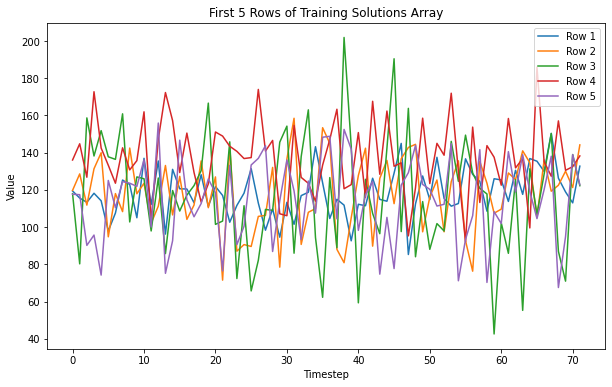

118.46743845932951


In [44]:
plt.figure(figsize=(10, 6))

for i in [0, 1, 2, 3, 4]:
    plt.plot(novel_samples_input[i, :], label=f'Row {i+1}')

plt.xlabel('Timestep')
plt.ylabel('Value')
plt.title('First 5 Rows of Training Solutions Array')
plt.legend()
plt.show()
print(np.mean(novel_samples_input[0,:]))

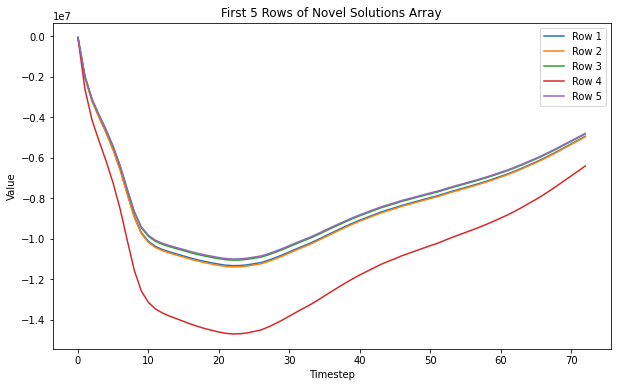

In [39]:
plt.figure(figsize=(10, 6))

for i in [0, 1, 2, 3, 4]:
    plt.plot(novel_solutions_array[i, :], label=f'Row {i+1}')

plt.xlabel('Timestep')
plt.ylabel('Value')
plt.title('First 5 Rows of Novel Solutions Array')
plt.legend()
plt.show()

In [26]:
training_solutions_array = np.load("/home/chinahg/GCresearch/contrailuncertainty/start_here/generated_files/results/test_17/true_training_solutions.npy")
print(f"Training Solutions Array Shape: {training_solutions_array.shape}")
training_input_rhi_matrix = np.load("/home/chinahg/GCresearch/contrailuncertainty/start_here/generated_files/results/test_17/training_samples_matrix_offline_cleaned.npy")

Training Solutions Array Shape: (5, 73)


In [27]:
print(f"Training Input RHi Matrix Shape: {training_input_rhi_matrix.shape}")

Training Input RHi Matrix Shape: (2, 5, 73)


In [31]:
# Plot the RHi over time for each training run
RHi_values = training_input_rhi_matrix[0, :, :]  # Assuming the second row contains RHi values

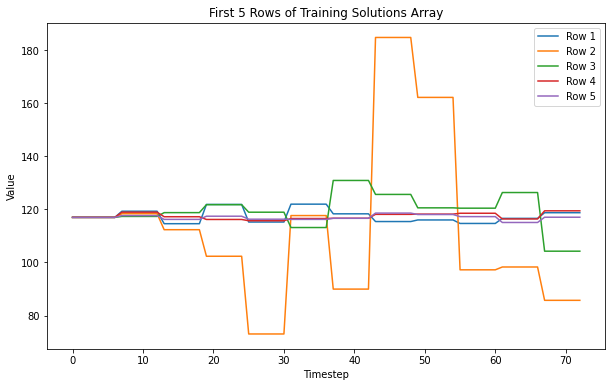

In [37]:
plt.figure(figsize=(10, 6))

for i in [0, 1, 2, 3, 4]:
    plt.plot(RHi_values[i, :] + 117, label=f'Row {i+1}')

plt.xlabel('Timestep')
plt.ylabel('Value')
plt.title('First 5 Rows of Training Solutions Array')
plt.legend()
plt.show()

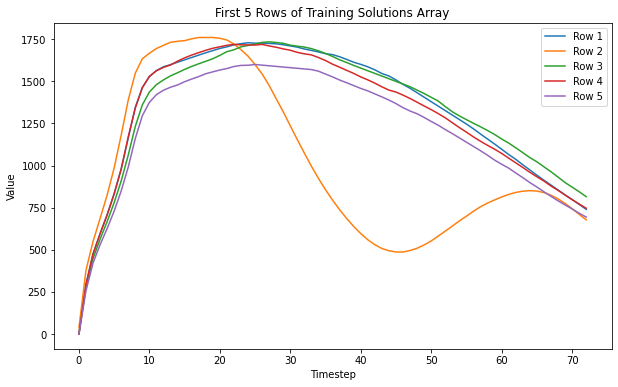

In [25]:
plt.figure(figsize=(10, 6))

for i in range(5):
    plt.plot(training_solutions_array[i, :], label=f'Row {i+1}')

plt.xlabel('Timestep')
plt.ylabel('Value')
plt.title('First 5 Rows of Training Solutions Array')
plt.legend()
plt.show()

## Do the same analysis for MLD